In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


# No Helmet Violation Detection
## WandB setup

In [3]:
import os
import wandb
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_key)


DATA_YAML = '/kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible/data.yaml'
OUTPUT_DIR = '/kaggle/working/plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tamangangel2057 (tamangangel2057-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Setting Seed

In [4]:
import random
import torch
import numpy as np
from ultralytics import settings

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed set to: {seed}")

set_seed(42)

Seed set to: 42


## Distribution pre-augmentation

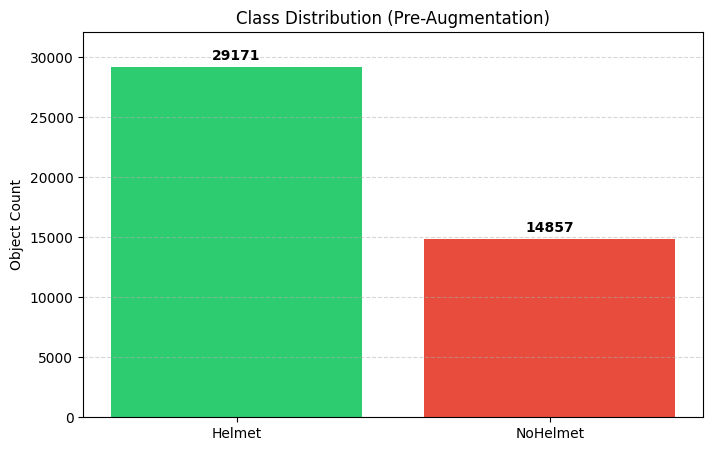

In [5]:
def plot_distribution(label_path, title, save_name):
    counts = {0: 0, 1: 0} # 0: Helmet, 1: NoHelmet
    
    # Iterate through labels
    for file in os.listdir(label_path):
        if file.endswith('.txt'):
            with open(os.path.join(label_path, file), 'r') as f:
                for line in f:
                    try:
                        cls = int(line.split()[0])
                        counts[cls] += 1
                    except (IndexError, ValueError):
                        continue
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ['Helmet', 'NoHelmet']
    values = [counts[0], counts[1]]
    colors = ['#2ecc71', '#e74c3c']
    
    bars = ax.bar(categories, values, color=colors)
    
    ax.bar_label(bars, padding=3, fontweight='bold')
    
    plt.title(title)
    plt.ylabel('Object Count')
    plt.ylim(0, max(values) * 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    save_path = os.path.join(OUTPUT_DIR, f"{save_name}.png")
    plt.savefig(save_path)
    plt.show()

# raw training data
train_labels = '/kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible/train/labels'
plot_distribution(train_labels, "Class Distribution (Pre-Augmentation)", "dist_before")

## Fix data.yaml working directory

In [6]:
import yaml

# Path to the original read-only YAML
original_yaml = '/kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible/data.yaml'
# Path where images actually live
dataset_root = '/kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible'

with open(original_yaml, 'r') as f:
    data = yaml.safe_load(f)

# Updating the 'path' to the absolute path of the input folder
data['path'] = dataset_root

# Saving this updated version to your working directory
local_yaml = '/kaggle/working/data_fixed.yaml'
with open(local_yaml, 'w') as f:
    yaml.dump(data, f)

In [7]:
wandb.init(project="Helmet Violation Detection", job_type="training", anonymous="allow")

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: setting up run z3xuln3t
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260319_085911-z3xuln3t
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run revived-terrain-1
wandb: ⭐️ View project at https://wandb.ai/tamangangel2057-student/Helmet%20Violation%20Detection
wandb: 🚀 View run at https://wandb.ai/tamangangel2057-student/Helmet%20Violation%20Detection/runs/z3xuln3t


In [8]:
# The two models we are training
models = ["yolo11n.pt", "yolo26n.pt"]

for m_name in models:
    model = YOLO(m_name)
    
    model.train(
        data=local_yaml,
        epochs=50,
        imgsz=640,
        batch=16,
        seed=42,           
        deterministic=True,
        augment=True,
        cache=True,
        project="Helmet_Detection_Comparison",
        name=m_name.split('.')[0],
        save=True,
        plots=True          # After Augmentation preview
    )

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

In [9]:
def plot_full_analysis(results_csv, model_name):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    
    fig, ax = plt.subplots(1, 3, figsize=(22, 6))
    
    # Localization Loss (Box)
    ax[0].plot(df['epoch'], df['train/box_loss'], label='Train Box', color='#1f77b4', linewidth=2)
    ax[0].plot(df['epoch'], df['val/box_loss'], label='Val Box', color='#ff7f0e', linestyle='--')
    ax[0].set_title(f'{model_name}: Localization (Box Loss)')
    ax[0].set_xlabel('Epochs')
    ax[0].legend()
    
    # Classification Loss
    ax[1].plot(df['epoch'], df['train/cls_loss'], label='Train Class', color='#9467bd', linewidth=2)
    ax[1].plot(df['epoch'], df['val/cls_loss'], label='Val Class', color='#2ca02c', linestyle='--')
    ax[1].set_title(f'{model_name}: Identification (Cls Loss)')
    ax[1].set_xlabel('Epochs')
    ax[1].legend()
    
    # Accuracy Metrics (mAP)
    ax[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#d62728', marker='o', markersize=3)
    ax[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#7f7f7f')
    ax[2].set_title(f'{model_name}: MAP Performance')
    ax[2].set_xlabel('Epochs')
    ax[2].legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_full_analysis.png")
    plt.show()



In [10]:
import shutil
import glob
import os

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

for m_name in ["yolo11n", "yolo26n"]:
    search_path = f"/kaggle/working/Helmet_Detection_Comparison/{m_name}*"
    matching_dirs = sorted(glob.glob(search_path))
    
    if matching_dirs:
        actual_run_dir = matching_dirs[-1]
        print(f"Harvesting from: {actual_run_dir}")
        
        # Copy Best Weights
        best_weight = f"{actual_run_dir}/weights/best.pt"
        if os.path.exists(best_weight):
            shutil.copy(best_weight, f"{OUTPUT_DIR}/{m_name}_best.pt")
        
        for plot_file in glob.glob(f"{actual_run_dir}/*.png") + glob.glob(f"{actual_run_dir}/*.jpg"):
            file_name = os.path.basename(plot_file)
            shutil.copy(plot_file, f"{OUTPUT_DIR}/{m_name}_{file_name}")
            
        csv_path = f"{actual_run_dir}/results.csv"
        if os.path.exists(csv_path):
            plot_full_analysis(csv_path, m_name)
    else:
        print(f"Error: Could not find directory for {m_name}")

shutil.make_archive('/kaggle/working/final_results', 'zip', OUTPUT_DIR)

Error: Could not find directory for yolo11n
Error: Could not find directory for yolo26n


'/kaggle/working/final_results.zip'